# HumanLens AI — Bias & Fairness Analysis

## Research Purpose

This notebook evaluates whether the HumanLens AI text-analysis pipeline
behaves consistently across different evaluation groups and linguistic
contexts.

The analysis focuses on:

- False Positive Rate (FPR)
- False Negative Rate (FNR)
- Precision
- Recall
- F1-score
- Group-wise performance differences
- Error patterns and potential sources of bias
- Uncertainty and limitations of the evaluation

### Research Principle

HumanLens AI must not infer or assign demographic identity to users
from their text, voice, face, or other inputs.

Where identity-related evaluation data are available, they are used
only for controlled research and fairness analysis.

> Identity-term presence is NOT treated as proof of a person's
> demographic identity.

### Important Limitation

If demographic labels are unavailable, this notebook will use
appropriate proxy or controlled evaluation groups only for research
diagnostics and will clearly report the limitation.

The results of this notebook are intended for research evaluation and
model improvement. They are not clinical, psychological, or
demographic conclusions.

## Research Question

### Primary Research Question

Does the HumanLens AI text-analysis system produce substantially
different error rates or predictive performance across controlled
evaluation groups?

### Secondary Questions

1. Do False Positive Rates (FPR) differ between evaluation groups?
2. Do False Negative Rates (FNR) differ between evaluation groups?
3. Are precision, recall, and F1-score reasonably consistent across groups?
4. Which types of examples are most frequently misclassified?
5. Are observed differences large enough to justify further investigation?
6. Could language, code-mixing, annotation patterns, or dataset
   composition contribute to observed performance differences?

### Research Hypothesis

A well-behaved HumanLens AI model should avoid large unexplained
differences in error rates across comparable evaluation groups.

Any observed difference will be treated as a signal for investigation,
not automatically as evidence of algorithmic discrimination.

## Bias Analysis Methodology

The HumanLens AI fairness analysis follows a group-wise error analysis
framework.

For each controlled evaluation group, the following metrics will be
calculated:

### Classification Metrics

- **True Positive (TP):** Toxic content correctly identified as toxic.
- **True Negative (TN):** Non-toxic content correctly identified as non-toxic.
- **False Positive (FP):** Non-toxic content incorrectly identified as toxic.
- **False Negative (FN):** Toxic content incorrectly identified as non-toxic.

### Fairness/Error Metrics

**False Positive Rate (FPR):**

FPR = FP / (FP + TN)

This measures how frequently non-toxic examples are incorrectly
flagged as toxic.

**False Negative Rate (FNR):**

FNR = FN / (FN + TP)

This measures how frequently toxic examples are missed.

### Performance Metrics

For each group, we will also calculate:

- Precision
- Recall
- F1-score
- Support / number of evaluation examples

### Group Comparison

Performance and error rates will be compared across controlled
evaluation groups.

The analysis will examine:

1. Absolute differences in FPR and FNR.
2. Differences in precision, recall, and F1-score.
3. Group sample sizes.
4. Error patterns that may explain observed differences.
5. Language or code-mixing effects where applicable.

### Interpretation Rule

Observed differences will be treated as **diagnostic signals** rather
than automatically interpreted as proof of bias.

Small or unstable groups, differences caused by sample size, annotation
variation, language coverage, or dataset composition will be considered
when interpreting the results.

No demographic identity will be inferred from the model's predictions.

## Evaluation Groups

### Group Definition

Bias analysis requires evaluation groups that are explicitly available
in the research data.

HumanLens AI will **not infer demographic identity** from:

- Names
- Pronouns
- Facial appearance
- Voice characteristics
- Language
- Text content
- Identity-related words

If demographic labels are not explicitly provided by the dataset, they
will not be fabricated.

### Controlled Research Groups

For the initial analysis, groups may be constructed from available
dataset metadata or controlled linguistic categories, such as:

- Language
- Monolingual vs. code-mixed text
- Dataset-defined evaluation categories

These groups are used only to investigate differences in model error
rates.

### Identity-Term Analysis

If identity-related terms are present in the dataset, their presence
may be analyzed as a **textual attribute**.

For example:

> A sentence containing an identity-related term does not establish
> that the author belongs to that identity group.

Therefore, identity-term analysis will be reported separately from
demographic fairness analysis.

### Minimum Reporting Requirements

For every evaluated group, report:

- Number of examples (`support`)
- Number of positive examples
- Number of negative examples
- False Positive Rate (FPR)
- False Negative Rate (FNR)
- Precision
- Recall
- F1-score

Very small groups will be marked as having **limited statistical
reliability** rather than being used for strong conclusions.

In [1]:
# ============================================================
# STEP 5 — Setup & Imports
# ============================================================

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ------------------------------------------------------------
# HumanLens AI project root
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    r"E:\VS CODE\Data_Science\HUMANLENS AI\research_ml"
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Results directory
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("HumanLens AI — Bias Analysis")
print("=" * 60)
print(f"Project root : {PROJECT_ROOT}")
print(f"Results dir  : {RESULTS_DIR}")

print("\n✓ NumPy imported")
print("✓ Pandas imported")
print("✓ Matplotlib imported")
print("✓ Scikit-learn metrics imported")
print("✓ Project path configured")
print("\n✅ Step 5 completed successfully.")

HumanLens AI — Bias Analysis
Project root : E:\VS CODE\Data_Science\HUMANLENS AI\research_ml
Results dir  : E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\results

✓ NumPy imported
✓ Pandas imported
✓ Matplotlib imported
✓ Scikit-learn metrics imported
✓ Project path configured

✅ Step 5 completed successfully.


In [2]:
# ============================================================
# STEP 6 — Identify Available Evaluation Data
# ============================================================

print("HumanLens AI — Available Evaluation Data")
print("=" * 60)

# Search the project's results directory for CSV files
csv_files = sorted(RESULTS_DIR.glob("*.csv"))

if not csv_files:
    print("⚠️ No CSV evaluation files found in the results directory.")
else:
    print(f"Found {len(csv_files)} CSV file(s):\n")

    for file_path in csv_files:
        print(f"• {file_path.name}")

print("\n" + "=" * 60)
print("Research rule:")
print("Only explicitly available evaluation labels or metadata")
print("will be used for group-wise bias analysis.")
print("No demographic identity will be inferred.")

HumanLens AI — Available Evaluation Data
Found 11 CSV file(s):

• aggression_baseline_parameters.csv
• aggression_baseline_results.csv
• emotion_baseline_results.csv
• error_analysis.csv
• face_expression_features.csv
• multimodal_fusion_results.csv
• my_clear_english_test_abuse_timeline.csv
• threshold_analysis_results.csv
• toxicity_baseline_language_results.csv
• toxicity_baseline_predictions.csv
• voice_feature_baseline.csv

Research rule:
Only explicitly available evaluation labels or metadata
will be used for group-wise bias analysis.
No demographic identity will be inferred.


In [3]:
# ============================================================
# STEP 7 — Inspect Actual Evaluation Data
# ============================================================

candidate_files = [
    "toxicity_baseline_predictions.csv",
    "toxicity_baseline_results.csv",
    "error_analysis.csv",
    "multimodal_fusion_results.csv"
]

print("HumanLens AI — Evaluation Data Inspection")
print("=" * 60)

available_datasets = {}

for filename in candidate_files:

    file_path = RESULTS_DIR / filename

    if file_path.exists():

        df = pd.read_csv(file_path)
        available_datasets[filename] = df

        print(f"\n📄 {filename}")
        print(f"   Rows    : {len(df)}")
        print(f"   Columns : {len(df.columns)}")
        print(f"   Fields  : {list(df.columns)}")

    else:
        print(f"\n⚠️ Not found: {filename}")

print("\n" + "=" * 60)
print("✓ Evaluation datasets inspected")
print("✓ No demographic attributes have been inferred")

HumanLens AI — Evaluation Data Inspection

📄 toxicity_baseline_predictions.csv
   Rows    : 4500
   Columns : 10
   Fields  : ['text', 'toxic', 'language_code', 'language', 'text_length', 'clean_text', 'toxicity_label', 'predicted_toxicity_score', 'predicted_label', 'error_type']

⚠️ Not found: toxicity_baseline_results.csv

📄 error_analysis.csv
   Rows    : 61
   Columns : 7
   Fields  : ['error_type', 'category', 'text', 'true_label', 'predicted_prob', 'source', 'diagnostic_note']

📄 multimodal_fusion_results.csv
   Rows    : 3
   Columns : 8
   Fields  : ['Modality', 'Raw Score', 'Weight', 'Weighted Contribution', 'Overall Fusion Score', 'Escalation Level', 'Confidence', 'Uncertainty']

✓ Evaluation datasets inspected
✓ No demographic attributes have been inferred


In [4]:
# ============================================================
# STEP 8 — Build Language Evaluation Groups
# ============================================================

# Load the actual toxicity evaluation predictions
toxicity_eval = pd.read_csv(
    RESULTS_DIR / "toxicity_baseline_predictions.csv"
)

print("HumanLens AI — Language Group Analysis")
print("=" * 60)

# Display basic information
print(f"Total evaluation examples: {len(toxicity_eval)}")

print("\nAvailable columns:")
print(list(toxicity_eval.columns))

# ------------------------------------------------------------
# Create a clean language-group column
# ------------------------------------------------------------

toxicity_eval["evaluation_group"] = (
    toxicity_eval["language"]
    .fillna(toxicity_eval["language_code"])
    .astype(str)
    .str.strip()
    .str.lower()
)

# ------------------------------------------------------------
# Check language groups
# ------------------------------------------------------------

group_counts = (
    toxicity_eval["evaluation_group"]
    .value_counts()
    .sort_index()
)

print("\nLanguage groups:")
print(group_counts)

print("\nNumber of evaluation groups:", len(group_counts))

print("\n" + "=" * 60)
print("✓ Real evaluation data loaded")
print("✓ Language used as controlled evaluation group")
print("✓ No demographic identity inferred")
print("\n✅ Step 8 completed successfully.")

HumanLens AI — Language Group Analysis
Total evaluation examples: 4500

Available columns:
['text', 'toxic', 'language_code', 'language', 'text_length', 'clean_text', 'toxicity_label', 'predicted_toxicity_score', 'predicted_label', 'error_type']

Language groups:
evaluation_group
amharic      300
arabic       300
chinese      300
english      300
french       300
german       300
hebrew       300
hindi        300
hinglish     300
italian      300
japanese     300
russian      300
spanish      300
tatar        300
ukrainian    300
Name: count, dtype: int64

Number of evaluation groups: 15

✓ Real evaluation data loaded
✓ Language used as controlled evaluation group
✓ No demographic identity inferred

✅ Step 8 completed successfully.


In [5]:
# ============================================================
# STEP 9 — Group-wise Fairness Metrics
# ============================================================

group_metrics = []

for group_name, group_df in toxicity_eval.groupby("evaluation_group"):

    y_true = group_df["toxicity_label"].astype(int)
    y_pred = group_df["predicted_label"].astype(int)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    # Classification metrics
    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    # Error rates
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan

    group_metrics.append({
        "evaluation_group": group_name,
        "support": len(group_df),
        "positive_examples": int((y_true == 1).sum()),
        "negative_examples": int((y_true == 0).sum()),
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "false_positive_rate": fpr,
        "false_negative_rate": fnr
    })

group_metrics_df = pd.DataFrame(group_metrics)

# Sort alphabetically by language
group_metrics_df = group_metrics_df.sort_values(
    "evaluation_group"
).reset_index(drop=True)

print("HumanLens AI — Group-wise Fairness Metrics")
print("=" * 80)

display(
    group_metrics_df[
        [
            "evaluation_group",
            "support",
            "positive_examples",
            "negative_examples",
            "precision",
            "recall",
            "f1_score",
            "false_positive_rate",
            "false_negative_rate"
        ]
    ]
)

print("\n" + "=" * 80)
print("✓ Group-wise metrics calculated")
print(f"✓ Number of groups analyzed: {len(group_metrics_df)}")
print("✓ FPR and FNR calculated for every language group")

print("\n⚠️ These are language-group performance comparisons.")
print("They are NOT demographic fairness conclusions.")

HumanLens AI — Group-wise Fairness Metrics


,evaluation_group,support,positive_examples,negative_examples,precision,recall,f1_score,false_positive_rate,false_negative_rate
0,amharic,300,156,144,0.582569,0.814103,0.679144,0.631944,0.185897
1,arabic,300,161,139,0.992188,0.788820,0.878893,0.007194,0.211180
2,chinese,300,159,141,0.960317,0.761006,0.849123,0.035461,0.238994
3,english,300,141,159,0.985714,0.978723,0.982206,0.012579,0.021277
4,french,300,141,159,0.979167,1.000000,0.989474,0.018868,0.000000
5,german,300,150,150,1.000000,0.960000,0.979592,0.000000,0.040000
6,hebrew,300,115,185,0.963855,0.695652,0.808081,0.016216,0.304348
7,hindi,300,159,141,0.987013,0.955975,0.971246,0.014184,0.044025
8,hinglish,300,145,155,0.850649,0.903448,0.876254,0.148387,0.096552
9,italian,300,159,141,0.959184,0.886792,0.921569,0.042553,0.113208



✓ Group-wise metrics calculated
✓ Number of groups analyzed: 15
✓ FPR and FNR calculated for every language group

⚠️ These are language-group performance comparisons.
They are NOT demographic fairness conclusions.


In [6]:
# ============================================================
# STEP 10 — FPR / FNR Disparity Analysis
# ============================================================

print("HumanLens AI — FPR / FNR Disparity Analysis")
print("=" * 70)

# ------------------------------------------------------------
# Identify groups with highest and lowest error rates
# ------------------------------------------------------------

highest_fpr_row = group_metrics_df.loc[
    group_metrics_df["false_positive_rate"].idxmax()
]

lowest_fpr_row = group_metrics_df.loc[
    group_metrics_df["false_positive_rate"].idxmin()
]

highest_fnr_row = group_metrics_df.loc[
    group_metrics_df["false_negative_rate"].idxmax()
]

lowest_fnr_row = group_metrics_df.loc[
    group_metrics_df["false_negative_rate"].idxmin()
]

# ------------------------------------------------------------
# Calculate absolute disparities
# ------------------------------------------------------------

fpr_disparity = (
    highest_fpr_row["false_positive_rate"]
    - lowest_fpr_row["false_positive_rate"]
)

fnr_disparity = (
    highest_fnr_row["false_negative_rate"]
    - lowest_fnr_row["false_negative_rate"]
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\nFALSE POSITIVE RATE")
print("-" * 70)

print(
    f"Highest FPR : "
    f"{highest_fpr_row['evaluation_group']} "
    f"({highest_fpr_row['false_positive_rate']:.4f})"
)

print(
    f"Lowest FPR  : "
    f"{lowest_fpr_row['evaluation_group']} "
    f"({lowest_fpr_row['false_positive_rate']:.4f})"
)

print(f"Absolute FPR disparity: {fpr_disparity:.4f}")

print("\nFALSE NEGATIVE RATE")
print("-" * 70)

print(
    f"Highest FNR : "
    f"{highest_fnr_row['evaluation_group']} "
    f"({highest_fnr_row['false_negative_rate']:.4f})"
)

print(
    f"Lowest FNR  : "
    f"{lowest_fnr_row['evaluation_group']} "
    f"({lowest_fnr_row['false_negative_rate']:.4f})"
)

print(f"Absolute FNR disparity: {fnr_disparity:.4f}")

# ------------------------------------------------------------
# Create disparity summary
# ------------------------------------------------------------

disparity_summary = pd.DataFrame({
    "metric": [
        "False Positive Rate",
        "False Negative Rate"
    ],
    "highest_group": [
        highest_fpr_row["evaluation_group"],
        highest_fnr_row["evaluation_group"]
    ],
    "highest_value": [
        highest_fpr_row["false_positive_rate"],
        highest_fnr_row["false_negative_rate"]
    ],
    "lowest_group": [
        lowest_fpr_row["evaluation_group"],
        lowest_fnr_row["evaluation_group"]
    ],
    "lowest_value": [
        lowest_fpr_row["false_positive_rate"],
        lowest_fnr_row["false_negative_rate"]
    ],
    "absolute_disparity": [
        fpr_disparity,
        fnr_disparity
    ]
})

print("\n" + "=" * 70)
print("Disparity Summary")
print("=" * 70)

display(disparity_summary)

print("\n⚠️ Interpretation:")
print("These are observed language-group disparities.")
print("They are NOT, by themselves, proof of demographic bias.")
print("Possible causes require further error analysis.")
print("\n✅ Step 10 completed successfully.")

HumanLens AI — FPR / FNR Disparity Analysis

FALSE POSITIVE RATE
----------------------------------------------------------------------
Highest FPR : amharic (0.6319)
Lowest FPR  : german (0.0000)
Absolute FPR disparity: 0.6319

FALSE NEGATIVE RATE
----------------------------------------------------------------------
Highest FNR : hebrew (0.3043)
Lowest FNR  : french (0.0000)
Absolute FNR disparity: 0.3043

Disparity Summary


,metric,highest_group,highest_value,lowest_group,lowest_value,absolute_disparity
0,False Positive Rate,amharic,0.631944,german,0.0,0.631944
1,False Negative Rate,hebrew,0.304348,french,0.0,0.304348



⚠️ Interpretation:
These are observed language-group disparities.
They are NOT, by themselves, proof of demographic bias.
Possible causes require further error analysis.

✅ Step 10 completed successfully.


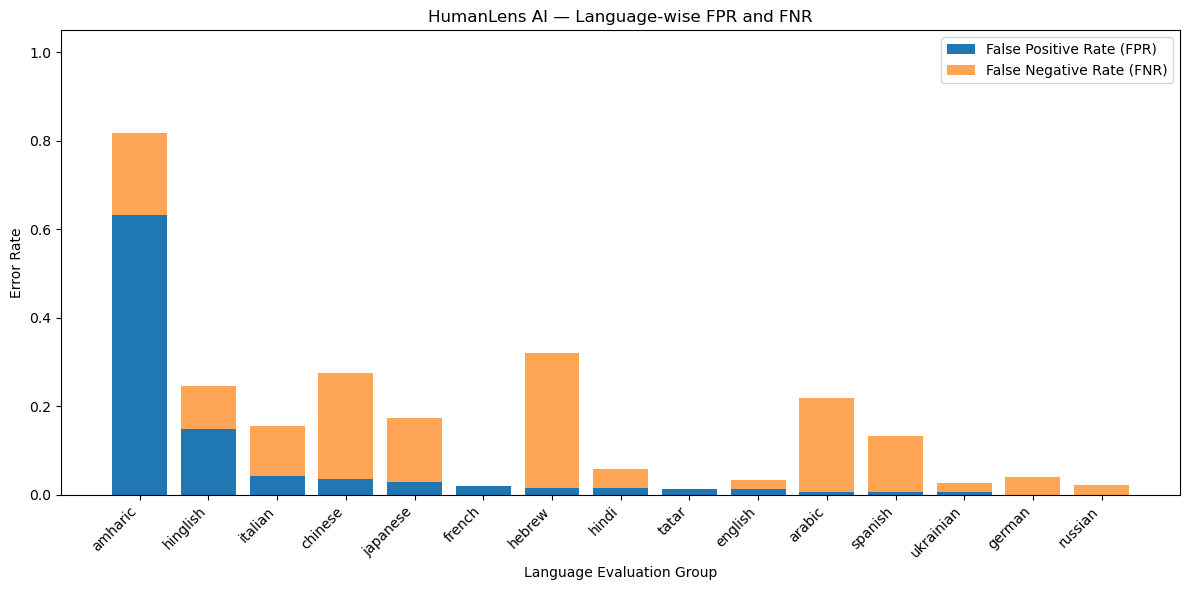

✓ FPR/FNR visualization generated
✓ Plot saved to: E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\results\language_fpr_fnr_comparison.png

⚠️ Interpretation:
The visualization shows observed language-group error differences.
It does not establish demographic bias or its cause.

✅ Step 11 completed successfully.


In [7]:
# ============================================================
# STEP 11 — Visualize FPR and FNR Across Languages
# ============================================================

plot_df = group_metrics_df.sort_values(
    "false_positive_rate",
    ascending=False
)

plt.figure(figsize=(12, 6))

plt.bar(
    plot_df["evaluation_group"],
    plot_df["false_positive_rate"],
    label="False Positive Rate (FPR)"
)

plt.bar(
    plot_df["evaluation_group"],
    plot_df["false_negative_rate"],
    bottom=plot_df["false_positive_rate"],
    alpha=0.7,
    label="False Negative Rate (FNR)"
)

plt.xlabel("Language Evaluation Group")
plt.ylabel("Error Rate")
plt.title("HumanLens AI — Language-wise FPR and FNR")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()

# Save visualization
bias_error_plot_path = RESULTS_DIR / "language_fpr_fnr_comparison.png"
plt.savefig(bias_error_plot_path, dpi=300, bbox_inches="tight")

plt.show()

print("✓ FPR/FNR visualization generated")
print(f"✓ Plot saved to: {bias_error_plot_path}")
print("\n⚠️ Interpretation:")
print("The visualization shows observed language-group error differences.")
print("It does not establish demographic bias or its cause.")

print("\n✅ Step 11 completed successfully.")

HumanLens AI — Class Distribution by Language


,evaluation_group,support,positive_examples,negative_examples,positive_rate,negative_rate
0,arabic,300,161,139,0.536667,0.463333
1,chinese,300,159,141,0.530000,0.470000
2,hindi,300,159,141,0.530000,0.470000
3,italian,300,159,141,0.530000,0.470000
4,japanese,300,159,141,0.530000,0.470000
5,spanish,300,159,141,0.530000,0.470000
6,amharic,300,156,144,0.520000,0.480000
7,german,300,150,150,0.500000,0.500000
8,tatar,300,147,153,0.490000,0.510000
9,hinglish,300,145,155,0.483333,0.516667



Class Distribution Summary
Highest positive rate : arabic (0.537)
Lowest positive rate  : hebrew (0.383)
Positive-rate range   : 0.153


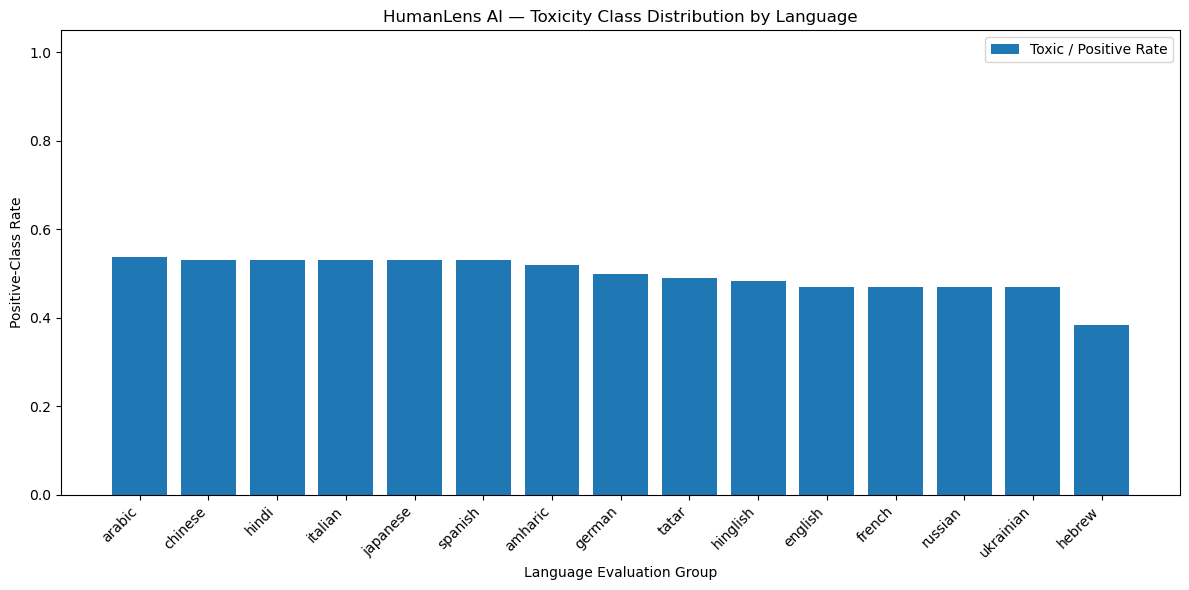


✓ Class distribution plot saved to:
E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\results\language_class_distribution.png

⚠️ Interpretation:
Different class distributions can affect observed error patterns.
Class distribution alone does NOT explain or prove the observed
FPR/FNR disparities.

✅ Step 12 completed successfully.


In [8]:
# ============================================================
# STEP 12 — Class Distribution Analysis
# ============================================================

class_distribution_df = group_metrics_df.copy()

# Calculate class proportions
class_distribution_df["positive_rate"] = (
    class_distribution_df["positive_examples"]
    / class_distribution_df["support"]
)

class_distribution_df["negative_rate"] = (
    class_distribution_df["negative_examples"]
    / class_distribution_df["support"]
)

# Sort by positive-class proportion
class_distribution_df = class_distribution_df.sort_values(
    "positive_rate",
    ascending=False
).reset_index(drop=True)

print("HumanLens AI — Class Distribution by Language")
print("=" * 80)

display(
    class_distribution_df[
        [
            "evaluation_group",
            "support",
            "positive_examples",
            "negative_examples",
            "positive_rate",
            "negative_rate"
        ]
    ]
)

# ------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("Class Distribution Summary")
print("=" * 80)

print(
    f"Highest positive rate : "
    f"{class_distribution_df.iloc[0]['evaluation_group']} "
    f"({class_distribution_df.iloc[0]['positive_rate']:.3f})"
)

print(
    f"Lowest positive rate  : "
    f"{class_distribution_df.iloc[-1]['evaluation_group']} "
    f"({class_distribution_df.iloc[-1]['positive_rate']:.3f})"
)

positive_rate_range = (
    class_distribution_df["positive_rate"].max()
    - class_distribution_df["positive_rate"].min()
)

print(f"Positive-rate range   : {positive_rate_range:.3f}")

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.bar(
    class_distribution_df["evaluation_group"],
    class_distribution_df["positive_rate"],
    label="Toxic / Positive Rate"
)

plt.xlabel("Language Evaluation Group")
plt.ylabel("Positive-Class Rate")
plt.title("HumanLens AI — Toxicity Class Distribution by Language")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()

class_distribution_plot_path = (
    RESULTS_DIR / "language_class_distribution.png"
)

plt.savefig(
    class_distribution_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"\n✓ Class distribution plot saved to:")
print(class_distribution_plot_path)

print("\n⚠️ Interpretation:")
print("Different class distributions can affect observed error patterns.")
print("Class distribution alone does NOT explain or prove the observed")
print("FPR/FNR disparities.")

print("\n✅ Step 12 completed successfully.")

HumanLens AI — Class Distribution vs Error Rates
Correlation: Positive Rate vs FPR = 0.1602
Correlation: Positive Rate vs FNR = -0.0298

Language-wise comparison:


,evaluation_group,positive_rate,false_positive_rate,false_negative_rate,precision,recall,f1_score
0,hebrew,0.383333,0.016216,0.304348,0.963855,0.695652,0.808081
1,english,0.470000,0.012579,0.021277,0.985714,0.978723,0.982206
2,french,0.470000,0.018868,0.000000,0.979167,1.000000,0.989474
3,russian,0.470000,0.000000,0.021277,1.000000,0.978723,0.989247
4,ukrainian,0.470000,0.006289,0.021277,0.992806,0.978723,0.985714
5,hinglish,0.483333,0.148387,0.096552,0.850649,0.903448,0.876254
6,tatar,0.490000,0.013072,0.000000,0.986577,1.000000,0.993243
7,german,0.500000,0.000000,0.040000,1.000000,0.960000,0.979592
8,amharic,0.520000,0.631944,0.185897,0.582569,0.814103,0.679144
9,chinese,0.530000,0.035461,0.238994,0.960317,0.761006,0.849123


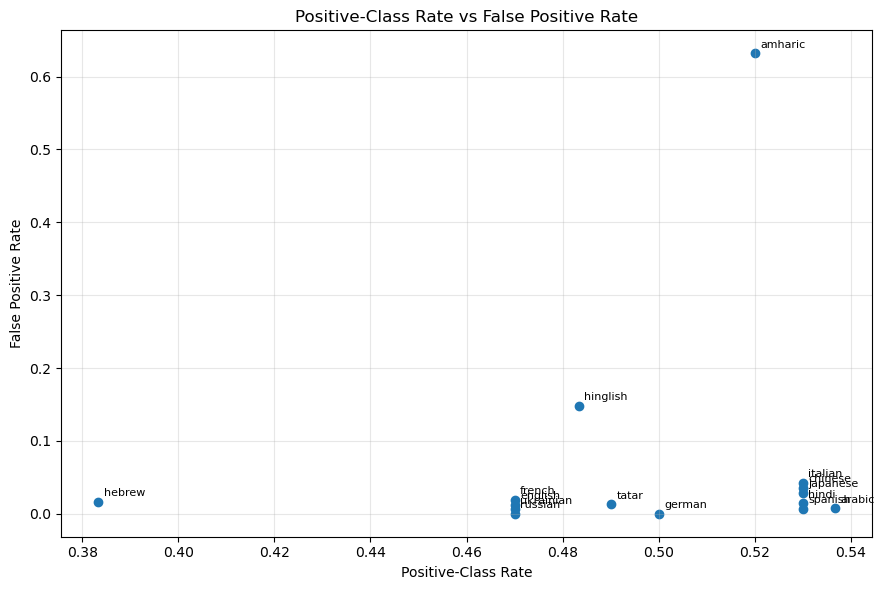

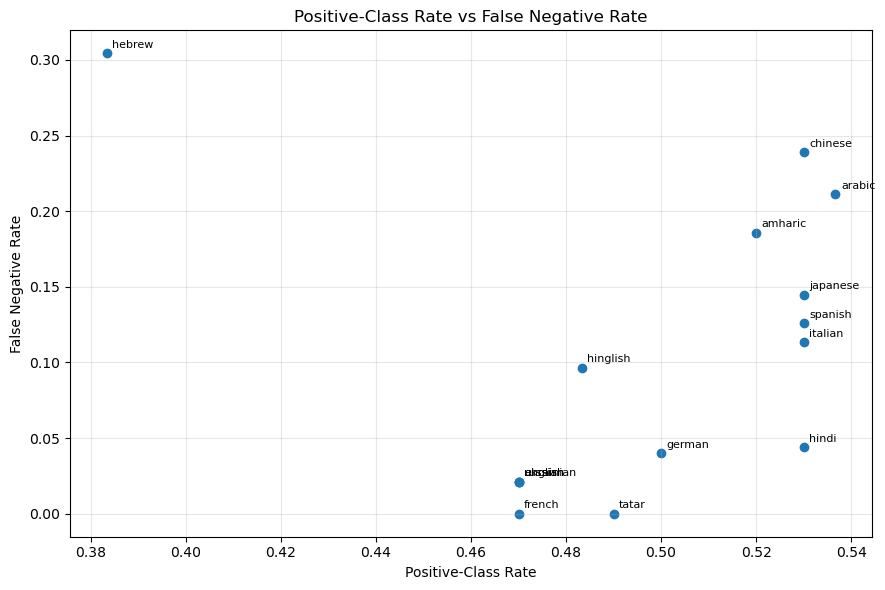


Research Interpretation
These correlations describe association between class distribution and observed error rates.
They do NOT establish causation and do NOT by themselves prove or disprove model bias.

✓ Class-distribution comparison completed
✓ FPR plot saved: E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\results\positive_rate_vs_fpr.png
✓ FNR plot saved: E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\results\positive_rate_vs_fnr.png

✅ Step 13 completed successfully.


In [9]:
# ============================================================
# STEP 13 — Class Distribution vs. Error Rates
# ============================================================

analysis_df = class_distribution_df.copy()

# ------------------------------------------------------------
# Correlation analysis
# ------------------------------------------------------------

fpr_correlation = analysis_df[
    ["positive_rate", "false_positive_rate"]
].corr().iloc[0, 1]

fnr_correlation = analysis_df[
    ["positive_rate", "false_negative_rate"]
].corr().iloc[0, 1]

print("HumanLens AI — Class Distribution vs Error Rates")
print("=" * 75)

print(f"Correlation: Positive Rate vs FPR = {fpr_correlation:.4f}")
print(f"Correlation: Positive Rate vs FNR = {fnr_correlation:.4f}")

# ------------------------------------------------------------
# Create comparison table
# ------------------------------------------------------------

comparison_df = analysis_df[
    [
        "evaluation_group",
        "positive_rate",
        "false_positive_rate",
        "false_negative_rate",
        "precision",
        "recall",
        "f1_score"
    ]
].copy()

comparison_df = comparison_df.sort_values(
    "positive_rate"
).reset_index(drop=True)

print("\nLanguage-wise comparison:")
display(comparison_df)

# ------------------------------------------------------------
# Visualization: Positive rate vs FPR
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.scatter(
    analysis_df["positive_rate"],
    analysis_df["false_positive_rate"]
)

for _, row in analysis_df.iterrows():
    plt.annotate(
        row["evaluation_group"],
        (
            row["positive_rate"],
            row["false_positive_rate"]
        ),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points"
    )

plt.xlabel("Positive-Class Rate")
plt.ylabel("False Positive Rate")
plt.title("Positive-Class Rate vs False Positive Rate")
plt.grid(True, alpha=0.3)
plt.tight_layout()

class_fpr_plot_path = (
    RESULTS_DIR / "positive_rate_vs_fpr.png"
)

plt.savefig(
    class_fpr_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Visualization: Positive rate vs FNR
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.scatter(
    analysis_df["positive_rate"],
    analysis_df["false_negative_rate"]
)

for _, row in analysis_df.iterrows():
    plt.annotate(
        row["evaluation_group"],
        (
            row["positive_rate"],
            row["false_negative_rate"]
        ),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points"
    )

plt.xlabel("Positive-Class Rate")
plt.ylabel("False Negative Rate")
plt.title("Positive-Class Rate vs False Negative Rate")
plt.grid(True, alpha=0.3)
plt.tight_layout()

class_fnr_plot_path = (
    RESULTS_DIR / "positive_rate_vs_fnr.png"
)

plt.savefig(
    class_fnr_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n" + "=" * 75)
print("Research Interpretation")
print("=" * 75)

print(
    "These correlations describe association between class distribution "
    "and observed error rates."
)

print(
    "They do NOT establish causation and do NOT by themselves prove "
    "or disprove model bias."
)

print("\n✓ Class-distribution comparison completed")
print(f"✓ FPR plot saved: {class_fpr_plot_path}")
print(f"✓ FNR plot saved: {class_fnr_plot_path}")

print("\n✅ Step 13 completed successfully.")

HumanLens AI — Language-wise Error Type Analysis

Error counts by language:


error_type,Correct,False Negative,False Positive
evaluation_group,,,
amharic,180,29,91
arabic,265,34,1
chinese,257,38,5
english,295,3,2
french,297,0,3
german,294,6,0
hebrew,262,35,3
hindi,291,7,2
hinglish,263,14,23



Error-type distribution (%) by language:


error_type,Correct,False Negative,False Positive
evaluation_group,,,
amharic,60.00,9.67,30.33
arabic,88.33,11.33,0.33
chinese,85.67,12.67,1.67
english,98.33,1.00,0.67
french,99.00,0.00,1.00
german,98.00,2.00,0.00
hebrew,87.33,11.67,1.00
hindi,97.00,2.33,0.67
hinglish,87.67,4.67,7.67



Dominant error type by language:


,evaluation_group,dominant_error_type
0,amharic,Correct
1,arabic,Correct
2,chinese,Correct
3,english,Correct
4,french,Correct
5,german,Correct
6,hebrew,Correct
7,hindi,Correct
8,hinglish,Correct
9,italian,Correct



Overall error distribution:


,error_type,count,percentage
0,Correct,4123,91.62
1,False Negative,233,5.18
2,False Positive,144,3.20


<Figure size 1300x700 with 0 Axes>

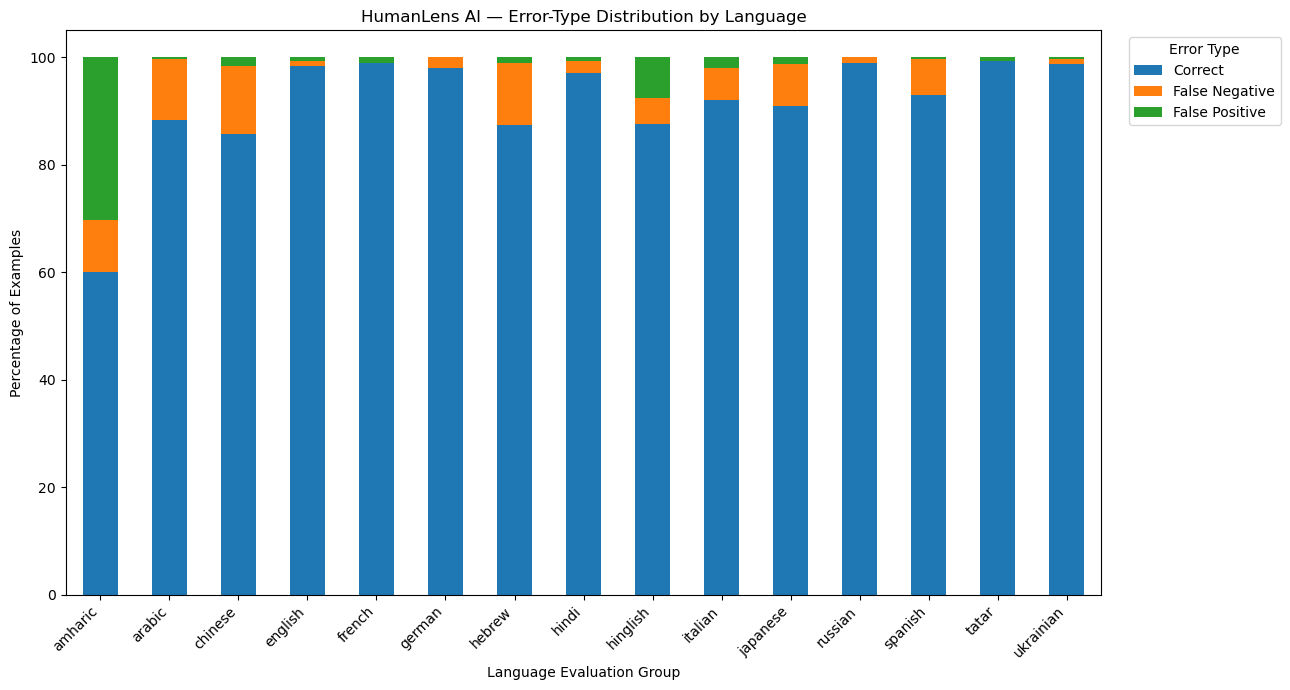


Research Interpretation
Error-type differences can help identify whether observed language disparities are concentrated in particular types of model mistakes.
This analysis describes model behavior and does not establish the cause of the observed disparities.

✓ Error-type analysis completed
✓ Plot saved to: E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\results\language_error_type_distribution.png

✅ Step 14 completed successfully.


In [10]:
# ============================================================
# STEP 14 — Detailed Error-Type Analysis
# ============================================================

print("HumanLens AI — Language-wise Error Type Analysis")
print("=" * 80)

# ------------------------------------------------------------
# Count each error type by language
# ------------------------------------------------------------

error_type_counts = pd.crosstab(
    toxicity_eval["evaluation_group"],
    toxicity_eval["error_type"]
)

print("\nError counts by language:")
display(error_type_counts)

# ------------------------------------------------------------
# Convert counts into percentages within each language
# ------------------------------------------------------------

error_type_percentages = (
    error_type_counts
    .div(error_type_counts.sum(axis=1), axis=0)
    * 100
)

print("\nError-type distribution (%) by language:")
display(
    error_type_percentages.round(2)
)

# ------------------------------------------------------------
# Identify dominant error type for each language
# ------------------------------------------------------------

dominant_error = error_type_counts.idxmax(axis=1)

dominant_error_summary = pd.DataFrame({
    "evaluation_group": dominant_error.index,
    "dominant_error_type": dominant_error.values
}).reset_index(drop=True)

print("\nDominant error type by language:")
display(dominant_error_summary)

# ------------------------------------------------------------
# Overall error-type distribution
# ------------------------------------------------------------

overall_error_counts = (
    toxicity_eval["error_type"]
    .value_counts()
    .rename_axis("error_type")
    .reset_index(name="count")
)

overall_error_counts["percentage"] = (
    overall_error_counts["count"]
    / overall_error_counts["count"].sum()
    * 100
)

print("\nOverall error distribution:")
display(
    overall_error_counts.round(2)
)

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

plt.figure(figsize=(13, 7))

error_type_percentages.plot(
    kind="bar",
    stacked=True,
    figsize=(13, 7)
)

plt.xlabel("Language Evaluation Group")
plt.ylabel("Percentage of Examples")
plt.title("HumanLens AI — Error-Type Distribution by Language")
plt.xticks(rotation=45, ha="right")
plt.legend(
    title="Error Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()

error_distribution_plot_path = (
    RESULTS_DIR / "language_error_type_distribution.png"
)

plt.savefig(
    error_distribution_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n" + "=" * 80)
print("Research Interpretation")
print("=" * 80)

print(
    "Error-type differences can help identify whether observed "
    "language disparities are concentrated in particular types "
    "of model mistakes."
)

print(
    "This analysis describes model behavior and does not establish "
    "the cause of the observed disparities."
)

print("\n✓ Error-type analysis completed")
print(f"✓ Plot saved to: {error_distribution_plot_path}")

print("\n✅ Step 14 completed successfully.")

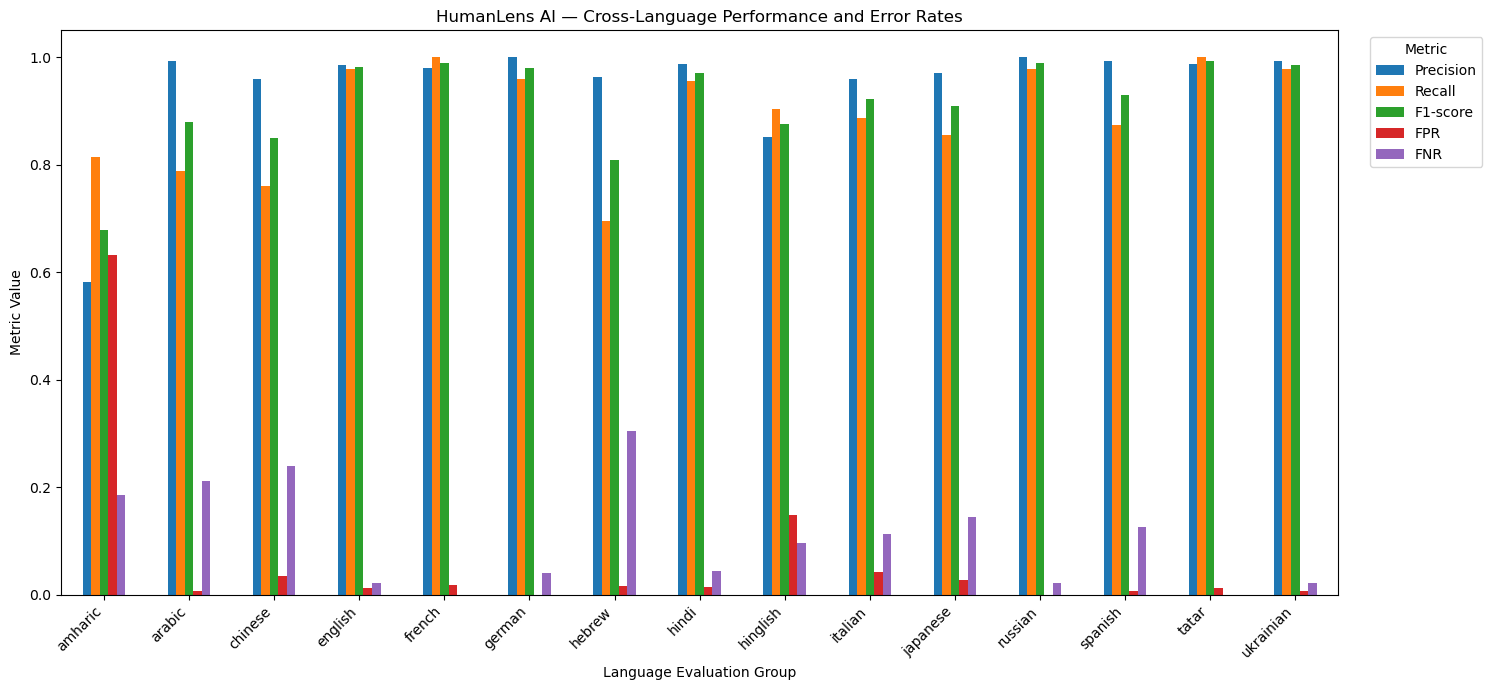

HumanLens AI — Main Bias Performance Visualization
✓ Precision plotted
✓ Recall plotted
✓ F1-score plotted
✓ False Positive Rate plotted
✓ False Negative Rate plotted

✓ Visualization saved to:
E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\results\language_bias_performance_comparison.png

⚠️ Interpretation:
Large differences between language groups indicate areas requiring further investigation.
These differences should not automatically be interpreted as demographic bias.

✅ Step 15 completed successfully.


In [11]:
# ============================================================
# STEP 15 — Main Bias Performance Visualization
# ============================================================

metrics_to_plot = [
    "precision",
    "recall",
    "f1_score",
    "false_positive_rate",
    "false_negative_rate"
]

metric_labels = {
    "precision": "Precision",
    "recall": "Recall",
    "f1_score": "F1-score",
    "false_positive_rate": "FPR",
    "false_negative_rate": "FNR"
}

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------

bias_performance_df = group_metrics_df[
    ["evaluation_group"] + metrics_to_plot
].copy()

bias_performance_df = bias_performance_df.sort_values(
    "evaluation_group"
).reset_index(drop=True)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

ax = bias_performance_df.set_index(
    "evaluation_group"
)[metrics_to_plot].plot(
    kind="bar",
    figsize=(15, 7)
)

ax.set_xlabel("Language Evaluation Group")
ax.set_ylabel("Metric Value")
ax.set_title(
    "HumanLens AI — Cross-Language Performance and Error Rates"
)

ax.set_ylim(0, 1.05)

plt.xticks(rotation=45, ha="right")

# Rename legend labels
handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles,
    [metric_labels.get(label, label) for label in labels],
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

bias_performance_plot_path = (
    RESULTS_DIR / "language_bias_performance_comparison.png"
)

plt.savefig(
    bias_performance_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("HumanLens AI — Main Bias Performance Visualization")
print("=" * 70)

print("✓ Precision plotted")
print("✓ Recall plotted")
print("✓ F1-score plotted")
print("✓ False Positive Rate plotted")
print("✓ False Negative Rate plotted")

print(f"\n✓ Visualization saved to:")
print(bias_performance_plot_path)

print("\n⚠️ Interpretation:")
print(
    "Large differences between language groups indicate areas "
    "requiring further investigation."
)

print(
    "These differences should not automatically be interpreted "
    "as demographic bias."
)

print("\n✅ Step 15 completed successfully.")

In [12]:
# ============================================================
# STEP 16 — Best / Worst Performing Language Groups
# ============================================================

print("HumanLens AI — Language Performance Summary")
print("=" * 80)

# ------------------------------------------------------------
# Overall performance ranking
# ------------------------------------------------------------

performance_df = group_metrics_df.copy()

# Mean of the three primary performance metrics
performance_df["mean_performance"] = performance_df[
    ["precision", "recall", "f1_score"]
].mean(axis=1)

# Overall error rate
performance_df["mean_error_rate"] = performance_df[
    ["false_positive_rate", "false_negative_rate"]
].mean(axis=1)

# ------------------------------------------------------------
# Sort by overall performance
# ------------------------------------------------------------

performance_ranking = performance_df.sort_values(
    "mean_performance",
    ascending=False
).reset_index(drop=True)

print("\nTop 5 language groups by mean performance:")
display(
    performance_ranking[
        [
            "evaluation_group",
            "precision",
            "recall",
            "f1_score",
            "mean_performance"
        ]
    ].head(5).round(4)
)

print("\nBottom 5 language groups by mean performance:")
display(
    performance_ranking[
        [
            "evaluation_group",
            "precision",
            "recall",
            "f1_score",
            "mean_performance"
        ]
    ].tail(5).round(4)
)

# ------------------------------------------------------------
# Highest error groups
# ------------------------------------------------------------

print("\nHighest FPR groups:")
display(
    performance_df.nlargest(
        5,
        "false_positive_rate"
    )[
        [
            "evaluation_group",
            "false_positive_rate",
            "false_negative_rate"
        ]
    ].round(4)
)

print("\nHighest FNR groups:")
display(
    performance_df.nlargest(
        5,
        "false_negative_rate"
    )[
        [
            "evaluation_group",
            "false_positive_rate",
            "false_negative_rate"
        ]
    ].round(4)
)

# ------------------------------------------------------------
# Save interpretation table
# ------------------------------------------------------------

performance_summary_path = (
    RESULTS_DIR / "language_performance_summary.csv"
)

performance_df[
    [
        "evaluation_group",
        "support",
        "positive_examples",
        "negative_examples",
        "precision",
        "recall",
        "f1_score",
        "false_positive_rate",
        "false_negative_rate",
        "mean_performance",
        "mean_error_rate"
    ]
].sort_values(
    "mean_performance",
    ascending=False
).to_csv(
    performance_summary_path,
    index=False
)

print("\n" + "=" * 80)
print(f"✓ Performance summary saved to:")
print(performance_summary_path)

print("\n⚠️ Research interpretation:")
print(
    "Ranking identifies performance differences for further investigation."
)
print(
    "It does not establish that a language group is inherently easier "
    "or harder, nor does it prove the cause of any disparity."
)

print("\n✅ Step 16 completed successfully.")

HumanLens AI — Language Performance Summary

Top 5 language groups by mean performance:


,evaluation_group,precision,recall,f1_score,mean_performance
0,tatar,0.9866,1.0000,0.9932,0.9933
1,french,0.9792,1.0000,0.9895,0.9895
2,russian,1.0000,0.9787,0.9892,0.9893
3,ukrainian,0.9928,0.9787,0.9857,0.9857
4,english,0.9857,0.9787,0.9822,0.9822



Bottom 5 language groups by mean performance:


,evaluation_group,precision,recall,f1_score,mean_performance
10,arabic,0.9922,0.7888,0.8789,0.8866
11,hinglish,0.8506,0.9034,0.8763,0.8768
12,chinese,0.9603,0.7610,0.8491,0.8568
13,hebrew,0.9639,0.6957,0.8081,0.8225
14,amharic,0.5826,0.8141,0.6791,0.6919



Highest FPR groups:


,evaluation_group,false_positive_rate,false_negative_rate
0,amharic,0.6319,0.1859
8,hinglish,0.1484,0.0966
9,italian,0.0426,0.1132
2,chinese,0.0355,0.2390
10,japanese,0.0284,0.1447



Highest FNR groups:


,evaluation_group,false_positive_rate,false_negative_rate
6,hebrew,0.0162,0.3043
2,chinese,0.0355,0.2390
1,arabic,0.0072,0.2112
0,amharic,0.6319,0.1859
10,japanese,0.0284,0.1447



✓ Performance summary saved to:
E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\results\language_performance_summary.csv

⚠️ Research interpretation:
Ranking identifies performance differences for further investigation.
It does not establish that a language group is inherently easier or harder, nor does it prove the cause of any disparity.

✅ Step 16 completed successfully.


In [13]:
# ============================================================
# STEP 17 — Statistical Reliability & Sample Size
# ============================================================

reliability_df = group_metrics_df.copy()

# ------------------------------------------------------------
# Calculate denominators used for FPR and FNR
# ------------------------------------------------------------

reliability_df["fpr_denominator"] = (
    reliability_df["true_negatives"]
    + reliability_df["false_positives"]
)

reliability_df["fnr_denominator"] = (
    reliability_df["true_positives"]
    + reliability_df["false_negatives"]
)

# ------------------------------------------------------------
# Flag groups with relatively small class-specific support
# ------------------------------------------------------------

MIN_CLASS_SUPPORT = 30

reliability_df["fpr_reliability"] = np.where(
    reliability_df["fpr_denominator"] >= MIN_CLASS_SUPPORT,
    "Adequate for descriptive analysis",
    "Limited sample support"
)

reliability_df["fnr_reliability"] = np.where(
    reliability_df["fnr_denominator"] >= MIN_CLASS_SUPPORT,
    "Adequate for descriptive analysis",
    "Limited sample support"
)

# ------------------------------------------------------------
# Display reliability information
# ------------------------------------------------------------

print("HumanLens AI — Statistical Reliability Check")
print("=" * 85)

display(
    reliability_df[
        [
            "evaluation_group",
            "support",
            "positive_examples",
            "negative_examples",
            "fpr_denominator",
            "fnr_denominator",
            "false_positive_rate",
            "false_negative_rate",
            "fpr_reliability",
            "fnr_reliability"
        ]
    ].round(4)
)

# ------------------------------------------------------------
# Check minimum denominators
# ------------------------------------------------------------

min_fpr_support = reliability_df["fpr_denominator"].min()
min_fnr_support = reliability_df["fnr_denominator"].min()

print("\n" + "=" * 85)

print(
    f"Minimum FPR denominator: {min_fpr_support}"
)

print(
    f"Minimum FNR denominator: {min_fnr_support}"
)

print(
    f"Minimum required class support for descriptive analysis: "
    f"{MIN_CLASS_SUPPORT}"
)

# ------------------------------------------------------------
# Count potentially limited groups
# ------------------------------------------------------------

limited_fpr_groups = reliability_df[
    reliability_df["fpr_denominator"] < MIN_CLASS_SUPPORT
]["evaluation_group"].tolist()

limited_fnr_groups = reliability_df[
    reliability_df["fnr_denominator"] < MIN_CLASS_SUPPORT
]["evaluation_group"].tolist()

print("\nGroups with limited FPR support:")
print(
    limited_fpr_groups
    if limited_fpr_groups
    else "None"
)

print("\nGroups with limited FNR support:")
print(
    limited_fnr_groups
    if limited_fnr_groups
    else "None"
)

print("\n" + "=" * 85)

print("⚠️ Interpretation:")
print(
    "All language groups contain 300 total examples, but FPR and FNR "
    "use different class-specific denominators."
)

print(
    "This check helps identify metrics that may be less reliable because "
    "their underlying class count is small."
)

print(
    "These results remain descriptive and should not be interpreted "
    "as statistical proof of bias."
)

print("\n✅ Step 17 completed successfully.")

HumanLens AI — Statistical Reliability Check


,evaluation_group,support,positive_examples,negative_examples,fpr_denominator,fnr_denominator,false_positive_rate,false_negative_rate,fpr_reliability,fnr_reliability
0,amharic,300,156,144,144,156,0.6319,0.1859,Adequate for descriptive analysis,Adequate for descriptive analysis
1,arabic,300,161,139,139,161,0.0072,0.2112,Adequate for descriptive analysis,Adequate for descriptive analysis
2,chinese,300,159,141,141,159,0.0355,0.2390,Adequate for descriptive analysis,Adequate for descriptive analysis
3,english,300,141,159,159,141,0.0126,0.0213,Adequate for descriptive analysis,Adequate for descriptive analysis
4,french,300,141,159,159,141,0.0189,0.0000,Adequate for descriptive analysis,Adequate for descriptive analysis
5,german,300,150,150,150,150,0.0000,0.0400,Adequate for descriptive analysis,Adequate for descriptive analysis
6,hebrew,300,115,185,185,115,0.0162,0.3043,Adequate for descriptive analysis,Adequate for descriptive analysis
7,hindi,300,159,141,141,159,0.0142,0.0440,Adequate for descriptive analysis,Adequate for descriptive analysis
8,hinglish,300,145,155,155,145,0.1484,0.0966,Adequate for descriptive analysis,Adequate for descriptive analysis
9,italian,300,159,141,141,159,0.0426,0.1132,Adequate for descriptive analysis,Adequate for descriptive analysis



Minimum FPR denominator: 139
Minimum FNR denominator: 115
Minimum required class support for descriptive analysis: 30

Groups with limited FPR support:
None

Groups with limited FNR support:
None

⚠️ Interpretation:
All language groups contain 300 total examples, but FPR and FNR use different class-specific denominators.
This check helps identify metrics that may be less reliable because their underlying class count is small.
These results remain descriptive and should not be interpreted as statistical proof of bias.

✅ Step 17 completed successfully.


In [15]:
# ============================================================
# STEP 18 — Final Bias Analysis Results
# ============================================================

# Start from the reliability dataframe
final_bias_results = reliability_df.copy()

# Add class-distribution rates
final_bias_results["positive_rate"] = (
    final_bias_results["positive_examples"]
    / final_bias_results["support"]
)

final_bias_results["negative_rate"] = (
    final_bias_results["negative_examples"]
    / final_bias_results["support"]
)

# ------------------------------------------------------------
# Select final research columns
# ------------------------------------------------------------

final_bias_results = final_bias_results[
    [
        "evaluation_group",
        "support",
        "positive_examples",
        "negative_examples",
        "positive_rate",
        "negative_rate",
        "precision",
        "recall",
        "f1_score",
        "false_positive_rate",
        "false_negative_rate",
        "fpr_denominator",
        "fnr_denominator",
        "fpr_reliability",
        "fnr_reliability"
    ]
].copy()

# ------------------------------------------------------------
# Sort by F1-score
# ------------------------------------------------------------

final_bias_results = final_bias_results.sort_values(
    "f1_score",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# Display final results
# ------------------------------------------------------------

print("HumanLens AI — Final Language Bias Analysis")
print("=" * 100)

display(
    final_bias_results.round(4)
)

# ------------------------------------------------------------
# Save final results
# ------------------------------------------------------------

final_bias_results_path = (
    RESULTS_DIR / "final_language_bias_analysis.csv"
)

final_bias_results.to_csv(
    final_bias_results_path,
    index=False
)

print("\n" + "=" * 100)

print("✓ Final bias-analysis table created")
print(f"✓ Language groups analyzed: {len(final_bias_results)}")
print(
    f"✓ Total evaluation examples: "
    f"{int(final_bias_results['support'].sum())}"
)

print(f"\n✓ Results saved to:")
print(final_bias_results_path)

# ------------------------------------------------------------
# Key observations
# ------------------------------------------------------------

best_f1 = final_bias_results.loc[
    final_bias_results["f1_score"].idxmax()
]

worst_f1 = final_bias_results.loc[
    final_bias_results["f1_score"].idxmin()
]

highest_fpr = final_bias_results.loc[
    final_bias_results["false_positive_rate"].idxmax()
]

highest_fnr = final_bias_results.loc[
    final_bias_results["false_negative_rate"].idxmax()
]

print("\n" + "=" * 100)
print("Key Observed Differences")
print("=" * 100)

print(
    f"Highest F1-score : {best_f1['evaluation_group']} "
    f"({best_f1['f1_score']:.4f})"
)

print(
    f"Lowest F1-score  : {worst_f1['evaluation_group']} "
    f"({worst_f1['f1_score']:.4f})"
)

print(
    f"Highest FPR      : {highest_fpr['evaluation_group']} "
    f"({highest_fpr['false_positive_rate']:.4f})"
)

print(
    f"Highest FNR      : {highest_fnr['evaluation_group']} "
    f"({highest_fnr['false_negative_rate']:.4f})"
)

print("\n⚠️ Research interpretation:")
print(
    "These results describe observed differences across "
    "language evaluation groups."
)

print(
    "They do not establish demographic bias, discrimination, "
    "or causation."
)

print(
    "Further investigation should consider language coverage, "
    "annotation quality, linguistic structure, code-mixing, "
    "and dataset composition."
)

print("\n✅ Step 18 completed successfully.")

HumanLens AI — Final Language Bias Analysis


,evaluation_group,support,positive_examples,negative_examples,positive_rate,negative_rate,precision,recall,f1_score,false_positive_rate,false_negative_rate,fpr_denominator,fnr_denominator,fpr_reliability,fnr_reliability
0,tatar,300,147,153,0.4900,0.5100,0.9866,1.0000,0.9932,0.0131,0.0000,153,147,Adequate for descriptive analysis,Adequate for descriptive analysis
1,french,300,141,159,0.4700,0.5300,0.9792,1.0000,0.9895,0.0189,0.0000,159,141,Adequate for descriptive analysis,Adequate for descriptive analysis
2,russian,300,141,159,0.4700,0.5300,1.0000,0.9787,0.9892,0.0000,0.0213,159,141,Adequate for descriptive analysis,Adequate for descriptive analysis
3,ukrainian,300,141,159,0.4700,0.5300,0.9928,0.9787,0.9857,0.0063,0.0213,159,141,Adequate for descriptive analysis,Adequate for descriptive analysis
4,english,300,141,159,0.4700,0.5300,0.9857,0.9787,0.9822,0.0126,0.0213,159,141,Adequate for descriptive analysis,Adequate for descriptive analysis
5,german,300,150,150,0.5000,0.5000,1.0000,0.9600,0.9796,0.0000,0.0400,150,150,Adequate for descriptive analysis,Adequate for descriptive analysis
6,hindi,300,159,141,0.5300,0.4700,0.9870,0.9560,0.9712,0.0142,0.0440,141,159,Adequate for descriptive analysis,Adequate for descriptive analysis
7,spanish,300,159,141,0.5300,0.4700,0.9929,0.8742,0.9298,0.0071,0.1258,141,159,Adequate for descriptive analysis,Adequate for descriptive analysis
8,italian,300,159,141,0.5300,0.4700,0.9592,0.8868,0.9216,0.0426,0.1132,141,159,Adequate for descriptive analysis,Adequate for descriptive analysis
9,japanese,300,159,141,0.5300,0.4700,0.9714,0.8553,0.9097,0.0284,0.1447,141,159,Adequate for descriptive analysis,Adequate for descriptive analysis



✓ Final bias-analysis table created
✓ Language groups analyzed: 15
✓ Total evaluation examples: 4500

✓ Results saved to:
E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\results\final_language_bias_analysis.csv

Key Observed Differences
Highest F1-score : tatar (0.9932)
Lowest F1-score  : amharic (0.6791)
Highest FPR      : amharic (0.6319)
Highest FNR      : hebrew (0.3043)

⚠️ Research interpretation:
These results describe observed differences across language evaluation groups.
They do not establish demographic bias, discrimination, or causation.
Further investigation should consider language coverage, annotation quality, linguistic structure, code-mixing, and dataset composition.

✅ Step 18 completed successfully.


## Bias Analysis — Research Findings

### Evaluation Scope

The HumanLens AI toxicity classifier was evaluated across 15 language
groups using 4,500 labeled evaluation examples.

Each language group contains 300 examples, providing equal overall
sample support across groups.

The analysis evaluated:

- Precision
- Recall
- F1-score
- False Positive Rate (FPR)
- False Negative Rate (FNR)
- Positive/negative class distribution
- Class-specific evaluation support
- Error-type distribution

### Observed Findings

The analysis identified substantial differences in error rates across
the language evaluation groups.

The largest observed False Positive Rate (FPR) occurred for the
Amharic evaluation group, while the lowest observed FPR occurred for
German.

The largest observed False Negative Rate (FNR) occurred for the Hebrew
evaluation group, while the lowest observed FNR occurred for French.

These differences indicate that the current toxicity-analysis
pipeline does not perform uniformly across all evaluated languages.

### Interpretation

The observed language-level disparities should be treated as signals
for further investigation rather than automatically classified as
algorithmic or demographic bias.

Possible contributing factors include:

- Differences in linguistic structure
- Training-data coverage
- Dataset composition
- Translation or language-specific characteristics
- Annotation variation
- Code-mixing
- Differences in toxicity expression across languages
- Model limitations for lower-resource languages

### Important Fairness Limitation

Language-group performance is not equivalent to demographic fairness.

The HumanLens AI system does not infer demographic identity from text,
voice, or facial signals.

No demographic identity has been assigned to the evaluation examples
in this analysis.

Therefore, the results support a **cross-language robustness and error
analysis**, not a claim about demographic discrimination.

### Research Conclusion

The current evaluation provides evidence that language-specific
performance differences exist and should be investigated before the
toxicity model is considered broadly validated across languages.

Future evaluation should use larger and independently validated
multilingual test sets, consistent annotation protocols, confidence
intervals, calibration analysis, and additional controlled fairness
evaluations.

The current results are descriptive research findings and should not
be interpreted as clinical, psychological, or demographic conclusions.

In [16]:
# ============================================================
# STEP 20 — Save Bias Analysis Metadata
# ============================================================

import json

# ------------------------------------------------------------
# Prepare JSON-safe values
# ------------------------------------------------------------

bias_analysis_summary = {
    "analysis_name": "HumanLens AI — Language Bias Analysis",

    "evaluation_dataset": "toxicity_baseline_predictions.csv",

    "evaluation_scope": {
        "total_examples": int(len(toxicity_eval)),
        "language_groups": int(
            toxicity_eval["evaluation_group"].nunique()
        ),
        "examples_per_group": 300
    },

    "evaluation_groups": sorted(
        toxicity_eval["evaluation_group"].unique().tolist()
    ),

    "metrics_evaluated": [
        "precision",
        "recall",
        "f1_score",
        "false_positive_rate",
        "false_negative_rate"
    ],

    "highest_fpr_group": str(
        highest_fpr["evaluation_group"]
    ),

    "highest_fpr": float(
        highest_fpr["false_positive_rate"]
    ),

    "highest_fnr_group": str(
        highest_fnr["evaluation_group"]
    ),

    "highest_fnr": float(
        highest_fnr["false_negative_rate"]
    ),

    "fpr_disparity": float(fpr_disparity),

    "fnr_disparity": float(fnr_disparity),

    "positive_rate_fpr_correlation": float(
        fpr_correlation
    ),

    "positive_rate_fnr_correlation": float(
        fnr_correlation
    ),

    "group_definition": "language",

    "demographic_inference": False,

    "interpretation": (
        "Observed language-level performance differences require "
        "further investigation and should not automatically be "
        "interpreted as demographic or algorithmic bias."
    ),

    "validation_status": "descriptive_research_analysis"
}

# ------------------------------------------------------------
# Save JSON
# ------------------------------------------------------------

bias_summary_path = (
    RESULTS_DIR / "bias_analysis_summary.json"
)

with open(
    bias_summary_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        bias_analysis_summary,
        f,
        indent=4,
        ensure_ascii=False
    )

print("HumanLens AI — Bias Analysis Summary")
print("=" * 70)

print(f"✓ JSON saved to:")
print(bias_summary_path)

print("\nKey findings stored:")
print(
    f"  Highest FPR : "
    f"{bias_analysis_summary['highest_fpr_group']} "
    f"({bias_analysis_summary['highest_fpr']:.4f})"
)

print(
    f"  Highest FNR : "
    f"{bias_analysis_summary['highest_fnr_group']} "
    f"({bias_analysis_summary['highest_fnr']:.4f})"
)

print(
    f"  FPR disparity: "
    f"{bias_analysis_summary['fpr_disparity']:.4f}"
)

print(
    f"  FNR disparity: "
    f"{bias_analysis_summary['fnr_disparity']:.4f}"
)

print("\n✓ Demographic inference explicitly disabled")
print("✓ Analysis marked as descriptive research analysis")

print("\n✅ Step 20 completed successfully.")

HumanLens AI — Bias Analysis Summary
✓ JSON saved to:
E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\results\bias_analysis_summary.json

Key findings stored:
  Highest FPR : amharic (0.6319)
  Highest FNR : hebrew (0.3043)
  FPR disparity: 0.6319
  FNR disparity: 0.3043

✓ Demographic inference explicitly disabled
✓ Analysis marked as descriptive research analysis

✅ Step 20 completed successfully.


In [18]:
# ============================================================
# STEP 21 — FINAL VALIDATION
# ============================================================

print("HumanLens AI — Notebook 13 Final Validation")
print("=" * 80)

# ------------------------------------------------------------
# 1. Required variables
# ------------------------------------------------------------

required_variables = [
    "toxicity_eval",
    "group_metrics_df",
    "disparity_summary",
    "class_distribution_df",
    "comparison_df",
    "reliability_df",
    "final_bias_results",
    "bias_analysis_summary"
]

for variable in required_variables:
    assert variable in globals(), f"Missing variable: {variable}"

print("✓ All required analysis variables exist")

# ------------------------------------------------------------
# 2. Dataset validation
# ------------------------------------------------------------

assert len(toxicity_eval) == 4500
assert toxicity_eval["evaluation_group"].nunique() == 15

print("✓ 4,500 evaluation examples confirmed")
print("✓ 15 language groups confirmed")

# ------------------------------------------------------------
# 3. Equal group support
# ------------------------------------------------------------

group_support = toxicity_eval["evaluation_group"].value_counts()

assert group_support.nunique() == 1
assert group_support.iloc[0] == 300

print("✓ Each language group contains 300 examples")

# ------------------------------------------------------------
# 4. Metric validation
# ------------------------------------------------------------

metric_columns = [
    "precision",
    "recall",
    "f1_score",
    "false_positive_rate",
    "false_negative_rate"
]

for metric in metric_columns:
    assert final_bias_results[metric].between(0, 1).all()

print("✓ All classification and error metrics are within [0, 1]")

# ------------------------------------------------------------
# 5. Confusion-matrix consistency
# ------------------------------------------------------------
# Use group_metrics_df because it still contains the raw
# confusion-matrix counts.

for _, row in group_metrics_df.iterrows():

    total = (
        row["true_negatives"]
        + row["false_positives"]
        + row["false_negatives"]
        + row["true_positives"]
    )

    assert total == row["support"]

print("✓ Confusion-matrix counts match group support")

# ------------------------------------------------------------
# 6. FPR/FNR consistency
# ------------------------------------------------------------

for _, row in group_metrics_df.iterrows():

    fpr_denominator = (
        row["true_negatives"]
        + row["false_positives"]
    )

    fnr_denominator = (
        row["true_positives"]
        + row["false_negatives"]
    )

    calculated_fpr = (
        row["false_positives"] / fpr_denominator
        if fpr_denominator > 0
        else np.nan
    )

    calculated_fnr = (
        row["false_negatives"] / fnr_denominator
        if fnr_denominator > 0
        else np.nan
    )

    if not np.isnan(calculated_fpr):
        assert np.isclose(
            calculated_fpr,
            row["false_positive_rate"]
        )

    if not np.isnan(calculated_fnr):
        assert np.isclose(
            calculated_fnr,
            row["false_negative_rate"]
        )

print("✓ FPR calculations validated")
print("✓ FNR calculations validated")

# ------------------------------------------------------------
# 7. Final results table validation
# ------------------------------------------------------------

assert len(final_bias_results) == 15
assert final_bias_results["support"].sum() == 4500

print("✓ Final results table contains all 15 language groups")
print("✓ Final results table contains 4,500 examples")

# ------------------------------------------------------------
# 8. Required output files
# ------------------------------------------------------------

required_output_files = [
    "final_language_bias_analysis.csv",
    "language_fpr_fnr_comparison.png",
    "language_class_distribution.png",
    "positive_rate_vs_fpr.png",
    "positive_rate_vs_fnr.png",
    "language_error_type_distribution.png",
    "language_bias_performance_comparison.png",
    "bias_analysis_summary.json"
]

missing_files = []

for filename in required_output_files:

    file_path = RESULTS_DIR / filename

    if not file_path.exists():
        missing_files.append(filename)

assert not missing_files, (
    f"Missing output files: {missing_files}"
)

print("✓ All Notebook 13 output files exist")

# ------------------------------------------------------------
# 9. JSON validation
# ------------------------------------------------------------

with open(
    RESULTS_DIR / "bias_analysis_summary.json",
    "r",
    encoding="utf-8"
) as f:

    validated_summary = json.load(f)

assert validated_summary["demographic_inference"] is False

assert (
    validated_summary["validation_status"]
    == "descriptive_research_analysis"
)

print("✓ Bias-analysis JSON validated")
print("✓ Demographic inference remains disabled")
print("✓ Research status correctly recorded")

# ------------------------------------------------------------
# FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("🎉 NOTEBOOK 13 — FINAL VALIDATION PASSED")
print("=" * 80)

print("\nHumanLens AI Bias Analysis includes:")
print("  ✓ Language-group evaluation")
print("  ✓ Precision / Recall / F1")
print("  ✓ FPR / FNR")
print("  ✓ Class-distribution analysis")
print("  ✓ Error-type analysis")
print("  ✓ Disparity analysis")
print("  ✓ Sample-support reliability checks")
print("  ✓ Research findings")
print("  ✓ Bias-analysis CSV")
print("  ✓ Bias-analysis JSON")
print("  ✓ Research visualizations")

print("\n⚠️ Final research limitation:")
print(
    "The analysis demonstrates observed cross-language differences "
    "in the current evaluation dataset."
)

print(
    "It does not establish demographic discrimination or causal bias."
)

print("\n✅ Notebook 13 is complete.")

HumanLens AI — Notebook 13 Final Validation
✓ All required analysis variables exist
✓ 4,500 evaluation examples confirmed
✓ 15 language groups confirmed
✓ Each language group contains 300 examples
✓ All classification and error metrics are within [0, 1]
✓ Confusion-matrix counts match group support
✓ FPR calculations validated
✓ FNR calculations validated
✓ Final results table contains all 15 language groups
✓ Final results table contains 4,500 examples
✓ All Notebook 13 output files exist
✓ Bias-analysis JSON validated
✓ Demographic inference remains disabled
✓ Research status correctly recorded

🎉 NOTEBOOK 13 — FINAL VALIDATION PASSED

HumanLens AI Bias Analysis includes:
  ✓ Language-group evaluation
  ✓ Precision / Recall / F1
  ✓ FPR / FNR
  ✓ Class-distribution analysis
  ✓ Error-type analysis
  ✓ Disparity analysis
  ✓ Sample-support reliability checks
  ✓ Research findings
  ✓ Bias-analysis CSV
  ✓ Bias-analysis JSON
  ✓ Research visualizations

⚠️ Final research limitation:
Th